In [1]:
import pandas as pd

df_http = pd.read_json("metrics(http).json", lines=True)
df_https = pd.read_json("metrics(https).json", lines=True)
df_https

,type,data,metric
0,Metric,"{'name': 'vus', 'type': 'gauge', 'contains': '...",vus
1,Point,"{'time': '2026-04-02T12:24:52.1081827+02:00', ...",vus
2,Metric,"{'name': 'vus_max', 'type': 'gauge', 'contains...",vus_max
3,Point,"{'time': '2026-04-02T12:24:52.1081827+02:00', ...",vus_max
4,Metric,"{'name': 'http_reqs', 'type': 'counter', 'cont...",http_reqs
...,...,...,...
33323,Point,"{'time': '2026-04-02T12:26:51.1953988+02:00', ...",checks
33324,Point,"{'time': '2026-04-02T12:26:51.1953988+02:00', ...",data_sent
33325,Point,"{'time': '2026-04-02T12:26:51.1953988+02:00', ...",data_received
33326,Point,"{'time': '2026-04-02T12:26:51.1953988+02:00', ...",iteration_duration


In [2]:
df_https.columns

Index(['type', 'data', 'metric'], dtype='object')

In [3]:
https_points = df_https[df_https["type"] == "Point"].copy()
http_points = df_http[df_http["type"] == "Point"].copy()


In [4]:
expanded_http = pd.json_normalize(http_points["data"])
expanded_https = pd.json_normalize(https_points["data"])

In [5]:
expanded_http["metric"] = http_points["metric"].values
expanded_https["metric"] = https_points["metric"].values

In [6]:
expanded_https


,time,value,tags.expected_response,tags.group,tags.method,tags.name,tags.proto,tags.protocol,tags.scenario,tags.status,tags.url,tags.check,metric
0,2026-04-02T12:24:52.1081827+02:00,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vus
1,2026-04-02T12:24:52.1081827+02:00,50.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vus_max
2,2026-04-02T12:24:52.2146271+02:00,1.0000,true,,POST,auth_signup,HTTP/1.1,http,stress,201,auth_signup,NaN,http_reqs
3,2026-04-02T12:24:52.2146271+02:00,1077.6195,true,,POST,auth_signup,HTTP/1.1,http,stress,201,auth_signup,NaN,http_req_duration
4,2026-04-02T12:24:52.2146271+02:00,1.9985,true,,POST,auth_signup,HTTP/1.1,http,stress,201,auth_signup,NaN,http_req_blocked
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33307,2026-04-02T12:26:51.1953988+02:00,1.0000,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,storage 200,checks
33308,2026-04-02T12:26:51.1953988+02:00,1104.0000,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,data_sent
33309,2026-04-02T12:26:51.1953988+02:00,1559.0000,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,data_received
33310,2026-04-02T12:26:51.1953988+02:00,128.8929,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,iteration_duration


In [7]:
http_df = expanded_http[expanded_http["metric"] == "http_req_duration"].copy()
https_df = expanded_https[expanded_https["metric"] == "http_req_duration"].copy()

In [8]:
https_df["value"].max

<bound method Series.max of 3        1077.6195
13        726.5329
27        218.4388
37        141.7115
49        100.1035
           ...    
33249       3.2195
33263     121.2887
33273       3.8545
33289     121.0697
33299       6.1960
Name: value, Length: 2756, dtype: float64>

In [9]:
https_df = https_df.dropna(axis=1, how="all").copy()
http_df = http_df.dropna(axis=1, how="all").copy()

In [10]:
http_df["time"] = pd.to_datetime(http_df["time"])
http_df = http_df.sort_values("time")

https_df["time"] = pd.to_datetime(https_df["time"])
https_df = https_df.sort_values("time")

# Convert to seconds relative to first timestamp
http_df["time_sec"] = (http_df["time"] - http_df["time"].min()).dt.total_seconds()
https_df["time_sec"] = (https_df["time"] - https_df["time"].min()).dt.total_seconds()

In [11]:
https_df["time_sec"]

3          0.000000
13         0.728698
27         0.799234
37         0.870934
49         0.900433
            ...    
33249    118.725599
33263    118.847401
33273    118.851879
33289    118.972949
33299    118.980265
Name: time_sec, Length: 2756, dtype: float64

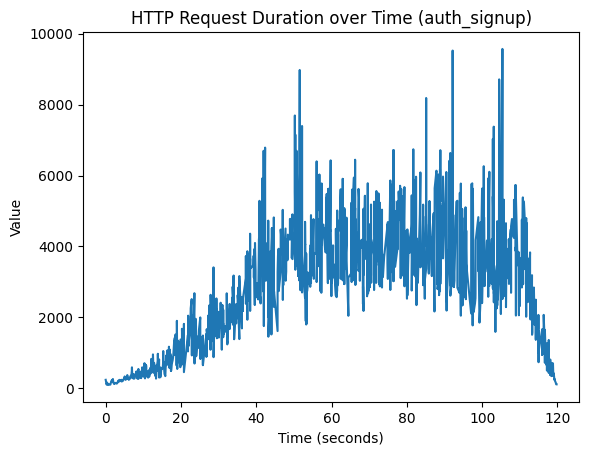

In [12]:
import matplotlib.pyplot as plt

plt.plot(http_df[http_df["tags.name"] == "auth_signup"].time_sec, http_df[http_df["tags.name"] == "auth_signup"].value, label="auth_signup")
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration over Time (auth_signup)")
plt.show()

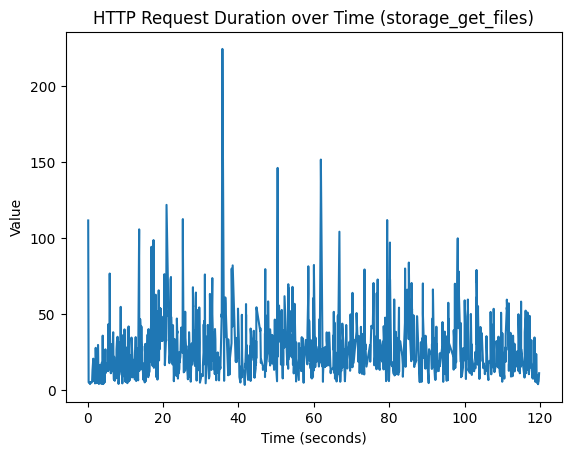

In [13]:
plt.plot(http_df[http_df["tags.name"] == "storage_get_files"].time_sec, http_df[http_df["tags.name"] == "storage_get_files"].value, label="storage_get_files")
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration over Time (storage_get_files)")
plt.show()

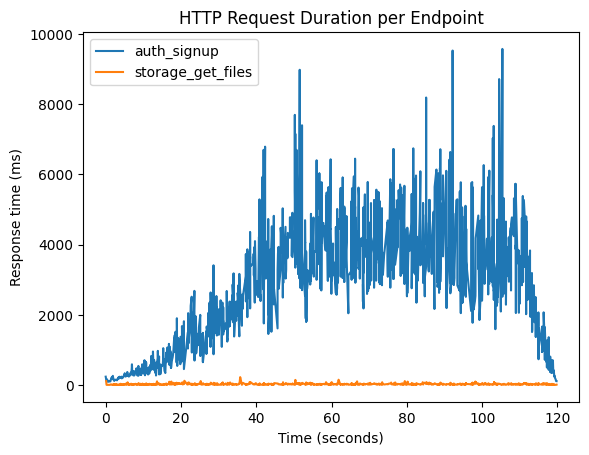

In [14]:


plt.plot(http_df[http_df["tags.name"] == "auth_signup"].time_sec, http_df[http_df["tags.name"] == "auth_signup"].value, label="auth_signup")
plt.plot(http_df[http_df["tags.name"] == "storage_get_files"].time_sec, http_df[http_df["tags.name"] == "storage_get_files"].value, label="storage_get_files")
plt.xlabel("Time (seconds)")
plt.ylabel("Response time (ms)")
plt.legend()
plt.title("HTTP Request Duration per Endpoint")
plt.show()

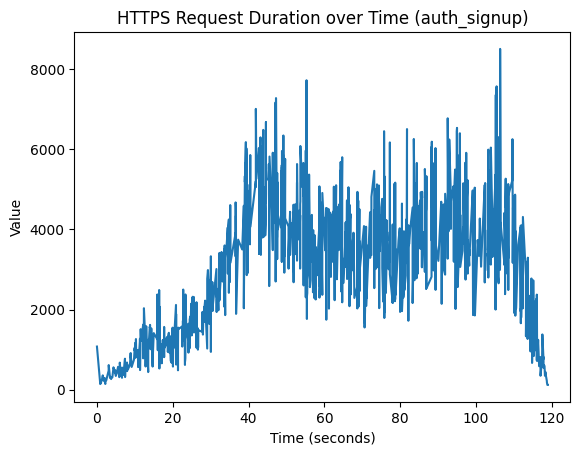

In [15]:
plt.plot(https_df[https_df["tags.name"] == "auth_signup"].time_sec, https_df[https_df["tags.name"] == "auth_signup"].value, label="auth_signup")
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTPS Request Duration over Time (auth_signup)")
plt.show()

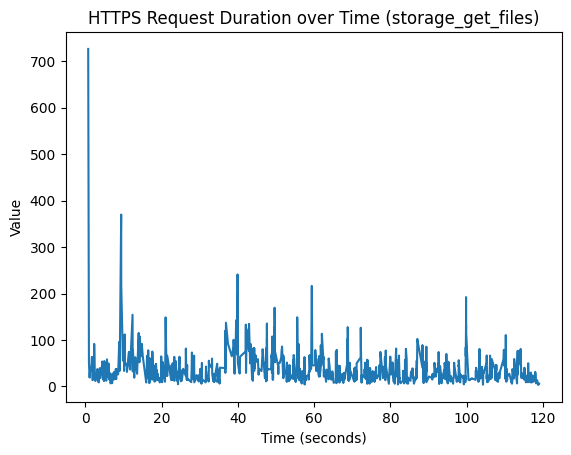

In [16]:
plt.plot(https_df[https_df["tags.name"] == "storage_get_files"].time_sec, https_df[https_df["tags.name"] == "storage_get_files"].value, label="storage_get_files")
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTPS Request Duration over Time (storage_get_files)")
plt.show()

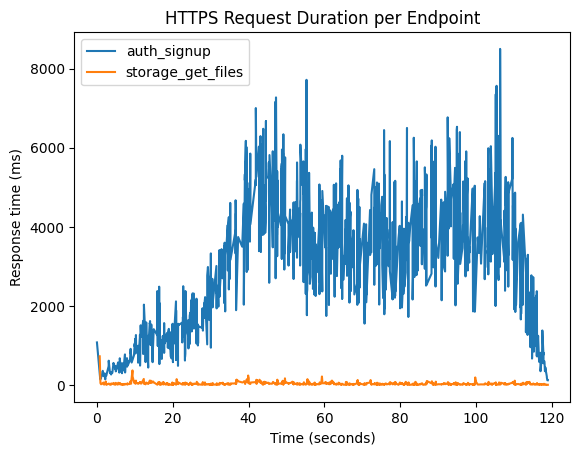

In [17]:
plt.plot(https_df[https_df["tags.name"] == "auth_signup"].time_sec, https_df[https_df["tags.name"] == "auth_signup"].value, label="auth_signup")
plt.plot(https_df[https_df["tags.name"] == "storage_get_files"].time_sec, https_df[https_df["tags.name"] == "storage_get_files"].value, label="storage_get_files")
plt.xlabel("Time (seconds)")
plt.ylabel("Response time (ms)")
plt.legend()
plt.title("HTTPS Request Duration per Endpoint")
plt.show()

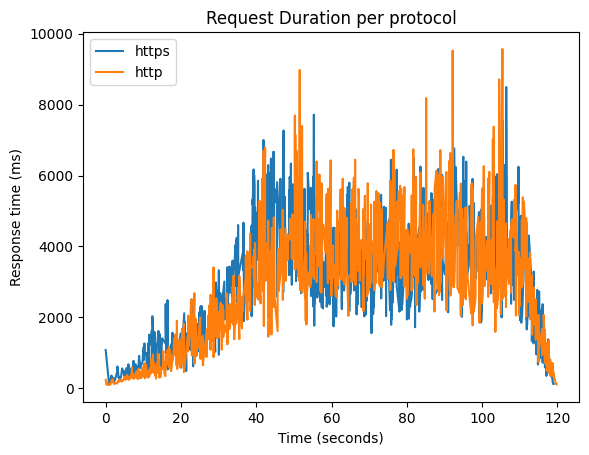

In [18]:
plt.plot(https_df[https_df["tags.name"] == "auth_signup"].time_sec, https_df[https_df["tags.name"] == "auth_signup"].value, label="https")
plt.plot(http_df[http_df["tags.name"] == "auth_signup"].time_sec, http_df[http_df["tags.name"] == "auth_signup"].value, label="http")
plt.xlabel("Time (seconds)")
plt.ylabel("Response time (ms)")
plt.legend()
plt.title("Request Duration per protocol")
plt.show()